In [ ]:
import os
import numpy as np
import pandas as pd
import rasterio
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import SGDClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score, log_loss
from imblearn.over_sampling import RandomOverSampler
from sklearn.model_selection import RandomizedSearchCV
import matplotlib.pyplot as plt

## Preparation Dataset

In [2]:
# Direktori data
image_dir = "E:\\FOLU NET SINK 2030\\benchmark_lulc_unaug\\Image"
mask_dir = "E:\\FOLU NET SINK 2030\\benchmark_lulc_unaug\\Mask"

In [3]:
# Fungsi untuk membaca image dan mask
def read_tif(file_path):
    with rasterio.open(file_path) as src:
        return src.read()

# Ekstrak data pixel dan label
def extract_pixels_and_labels(image_dir, mask_dir):
    pixels = []
    labels = []
    
    for image_file in os.listdir(image_dir):
        if image_file.startswith("data"):
            mask_file = "mask" + image_file[4:]
            image_path = os.path.join(image_dir, image_file)
            mask_path = os.path.join(mask_dir, mask_file)
            
            if os.path.exists(mask_path):
                # Baca data image dan mask
                image = read_tif(image_path)
                mask = read_tif(mask_path)[0]  # Ambil satu channel mask
                
                # Reshape menjadi array 1D
                image_reshaped = image.reshape(image.shape[0], -1).T  # (pixel_count, 7)
                mask_reshaped = mask.flatten()  # (pixel_count,)
                
                # Filter piksel dengan nilai mask > 0
                valid_pixels = image_reshaped[mask_reshaped > 0]
                valid_labels = mask_reshaped[mask_reshaped > 0]
                
                # Tambahkan ke list
                pixels.append(valid_pixels)
                labels.append(valid_labels)
    
    # Gabungkan semua data
    return np.vstack(pixels), np.hstack(labels)

# Baca data
pixels, labels = extract_pixels_and_labels(image_dir, mask_dir)

In [4]:
# Split data menjadi training dan testing
X_train, X_test, y_train, y_test = train_test_split(pixels, labels, test_size=0.2, random_state=42, stratify=labels)

22    18999441
11     7022917
21     5015779
13     3281171
33     2918593
60     2822972
34     2703844
41     2611910
71     1482418
15     1065959
72      602602
54      554034
81      342370
82       68777
Name: count, dtype: int64


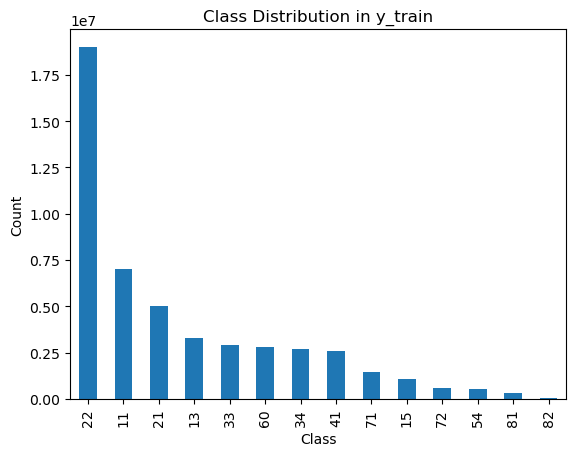

In [ ]:
# Cek distribusi kelas
class_counts = pd.Series(y_train).value_counts()
print(class_counts)

# Visualisasi distribusi kelas
class_counts.plot(kind='bar', title='Class Distribution in y_train')
plt.xlabel('Class')
plt.ylabel('Count')
plt.show()

22    18999441
11    18999441
13    18999441
21    18999441
34    18999441
71    18999441
60    18999441
15    18999441
33    18999441
54    18999441
41    18999441
81    18999441
82    18999441
72    18999441
Name: count, dtype: int64


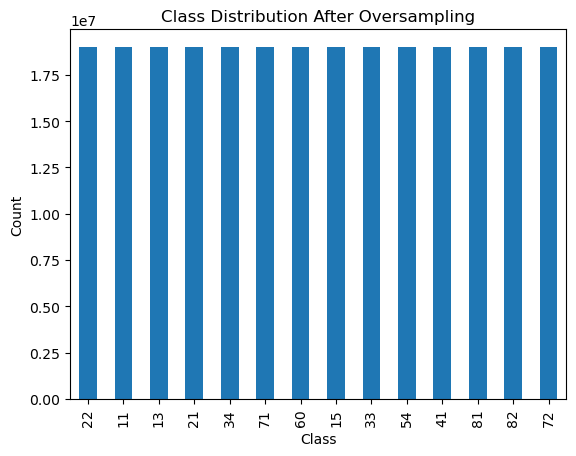

In [ ]:
# Oversampling untuk mengatasi imbalance proporsi kelas
ros = RandomOverSampler(random_state=42)
X_train_resampled, y_train_resampled = ros.fit_resample(X_train, y_train)

# Cek distribusi setelah resampling
resampled_counts = pd.Series(y_train_resampled).value_counts()
print(resampled_counts)

# Visualisasi
resampled_counts.plot(kind='bar', title='Class Distribution After Oversampling')
plt.xlabel('Class')
plt.ylabel('Count')
plt.show()

## Random Forest

In [ ]:
# Sampling subset untuk Random Forest atau Gradient Boosting
subset_size = 10000  # Contoh, ambil 100.000 sampel
X_train_resampled, _, y_train_resampled, _ = train_test_split(
    X_train, y_train, train_size=subset_size, random_state=42, stratify=y_train
)

In [ ]:
# Latih model
rf_model = RandomForestClassifier(n_estimators=500, random_state=42)
rf_model.fit(X_train_resampled, y_train_resampled)

RandomForestClassifier(n_estimators=500, random_state=42)

In [ ]:
# Evaluasi Random Forest
y_pred_rf = rf_model.predict(X_test)
y_pred_prob_rf = rf_model.predict_proba(X_test)

accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf, average="weighted", zero_division=0)
recall_rf = recall_score(y_test, y_pred_rf, average="weighted", zero_division=0)
f1_rf = f1_score(y_test, y_pred_rf, average="weighted", zero_division=0)
loss_rf = log_loss(y_test, y_pred_prob_rf)

print(f"Random Forest - Accuracy: {accuracy_rf}, \n Precision: {precision_rf}, \n Recall: {recall_rf}, \n F1: {f1_rf}, \n Loss: {loss_rf}")
print(classification_report(y_test, y_pred_rf))

Random Forest - Accuracy: 0.5697946133081047, Precision: 0.5428666046645587, Recall: 0.5697946133081047, F1: 0.5380506755464217, Loss: 1.5390825005807953


In [ ]:
#Uji Akurasi
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Random Forest Recall", precision_score(y_test, y_pred_rf, average="weighted", zero_division=0))
print("Random F")
print(classification_report(y_test, y_pred_rf))

Random Forest Accuracy: 0.5697946133081047
              precision    recall  f1-score   support

          11       0.57      0.45      0.50   1755730
          13       0.23      0.05      0.08    820293
          15       0.54      0.23      0.32    266490
          21       0.50      0.43      0.46   1253945
          22       0.58      0.84      0.69   4749860
          33       0.41      0.31      0.36    729648
          34       0.39      0.24      0.29    675961
          41       0.62      0.65      0.63    652977
          54       0.64      0.25      0.36    138508
          60       0.62      0.49      0.54    705743
          71       0.85      0.82      0.83    370605
          72       0.77      0.77      0.77    150651
          81       0.71      0.58      0.64     85592
          82       0.29      0.05      0.08     17194

    accuracy                           0.57  12373197
   macro avg       0.55      0.44      0.47  12373197
weighted avg       0.54      0.57    

## Gradient Boosting

In [14]:
# Gradient Boosting
gb_model = GradientBoostingClassifier(random_state=42)
gb_model.fit(X_train_subset, y_train_subset)

GradientBoostingClassifier(random_state=42)

In [ ]:
# Evaluasi Gradient Boosting
y_pred_gb = gb_model.predict(X_test)
y_pred_prob_gb = gb_model.predict_proba(X_test)

accuracy_gb = accuracy_score(y_test, y_pred_gb)
precision_gb = precision_score(y_test, y_pred_gb, average="weighted", zero_division=0)
recall_gb = recall_score(y_test, y_pred_gb, average="weighted", zero_division=0)
f1_gb = f1_score(y_test, y_pred_gb, average="weighted", zero_division=0)
loss_gb = log_loss(y_test, y_pred_prob_gb)

print(f"Random Forest - Accuracy: {accuracy_gb}, \n Precision: {precision_gb}, \n Recall: {recall_gb}, \n F1: {f1_gb}, \n Loss: {loss_gb}")
print(classification_report(y_test, y_pred_gb))

In [ ]:
print("Gradient Boosting Accuracy:", accuracy_score(y_test, y_pred_gb))
print(classification_report(y_test, y_pred_gb))

Gradient Boosting Accuracy: 0.5556213159784007
              precision    recall  f1-score   support

          11       0.58      0.41      0.48   1755730
          13       0.25      0.04      0.06    820293
          15       0.44      0.23      0.30    266490
          21       0.50      0.38      0.43   1253945
          22       0.57      0.84      0.68   4749860
          33       0.38      0.31      0.34    729648
          34       0.37      0.23      0.28    675961
          41       0.60      0.63      0.62    652977
          54       0.39      0.19      0.25    138508
          60       0.59      0.46      0.52    705743
          71       0.85      0.77      0.81    370605
          72       0.67      0.72      0.69    150651
          81       0.55      0.54      0.54     85592
          82       0.02      0.02      0.02     17194

    accuracy                           0.56  12373197
   macro avg       0.48      0.41      0.43  12373197
weighted avg       0.53      0.56

## Support Vector Machine

In [ ]:
# SVM dengan SGDClassifier
svm_model = SGDClassifier(loss="hinge", random_state=42)

# Batch training SVM
batch_size = 10000  # Sesuaikan dengan kapasitas memori Anda
classes = np.unique(y_train)

for i in range(0, X_train.shape[0], batch_size):
    X_batch = X_train[i:i + batch_size]
    y_batch = y_train[i:i + batch_size]
    svm_model.partial_fit(X_batch, y_batch, classes=classes)

In [ ]:
# Evaluasi SVM
y_pred_svm = svm_model.predict(X_test)
y_pred_prob_svm =svm_model.predict_proba(X_test)

accuracy_svm = accuracy_score(y_test, y_pred_svm)
precision_svm = precision_score(y_test, y_pred_svm, average="weighted", zero_division=0)
recall_svm = recall_score(y_test, y_pred_svm, average="weighted", zero_division=0)
f1_svm = f1_score(y_test, y_pred_svm, average="weighted", zero_division=0)
loss_svm = log_loss(y_test, y_pred_prob_svm)

print(f"Random Forest - Accuracy: {accuracy_svm}, \n Precision: {precision_svm}, \n Recall: {recall_svm}, \n F1: {f1_svm}, \n Loss: {loss_svm}")
print(classification_report(y_test, y_pred_svm))

In [ ]:
print("SVM Accuracy:", accuracy_score(y_test, y_pred_svm))
print(classification_report(y_test, y_pred_svm))


Gradient Boosting Accuracy: 0.3586491833921338


c:\Users\STUDIO 09\anaconda3\envs\folu\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\STUDIO 09\anaconda3\envs\folu\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


              precision    recall  f1-score   support

          11       0.29      0.00      0.00   1755730
          13       0.10      0.60      0.18    820293
          15       0.00      0.00      0.00    266490
          21       0.00      0.00      0.00   1253945
          22       0.53      0.67      0.59   4749860
          33       0.00      0.00      0.00    729648
          34       0.05      0.00      0.00    675961
          41       0.76      0.10      0.18    652977
          54       0.21      0.01      0.02    138508
          60       0.37      0.56      0.44    705743
          71       0.74      0.74      0.74    370605
          72       0.98      0.14      0.25    150651
          81       0.83      0.00      0.00     85592
          82       0.00      0.00      0.00     17194

    accuracy                           0.36  12373197
   macro avg       0.35      0.20      0.17  12373197
weighted avg       0.36      0.36      0.30  12373197



c:\Users\STUDIO 09\anaconda3\envs\folu\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


## Naive Bayes

In [ ]:
# Naive Bayes dengan GaussianNB
nb_model = GaussianNB()

# Batch training Naive Bayes
for i in range(0, X_train.shape[0], batch_size):
    X_batch = X_train[i:i + batch_size]
    y_batch = y_train[i:i + batch_size]
    nb_model.partial_fit(X_batch, y_batch, classes=classes)

In [ ]:
# Evaluasi Naive Bayes
y_pred_nb = nb_model.predict(X_test)
y_pred_prob_nb =nb_model.predict_proba(X_test)

accuracy_nb = accuracy_score(y_test, y_pred_nb)
precision_nb = precision_score(y_test, y_pred_nb, average="weighted", zero_division=0)
recall_nb = recall_score(y_test, y_pred_nb, average="weighted", zero_division=0)
f1_nb = f1_score(y_test, y_pred_nb, average="weighted", zero_division=0)
loss_nb = log_loss(y_test, y_pred_prob_nb)

print(f"Random Forest - Accuracy: {accuracy_nb}, \n Precision: {precision_nb}, \n Recall: {recall_nb}, \n F1: {f1_nb}, \n Loss: {loss_nb}")
print(classification_report(y_test, y_pred_nb))

In [ ]:
print("Naive Bayes Accuracy:", accuracy_score(y_test, y_pred_nb))
print(classification_report(y_test, y_pred_nb))

Gradient Boosting Accuracy: 0.46720568661438105


c:\Users\STUDIO 09\anaconda3\envs\folu\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\STUDIO 09\anaconda3\envs\folu\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


              precision    recall  f1-score   support

          11       0.50      0.15      0.23   1755730
          13       0.00      0.00      0.00    820293
          15       0.12      0.03      0.05    266490
          21       0.30      0.00      0.00   1253945
          22       0.50      0.88      0.64   4749860
          33       0.24      0.27      0.25    729648
          34       0.27      0.29      0.28    675961
          41       0.46      0.62      0.53    652977
          54       0.19      0.05      0.08    138508
          60       0.54      0.27      0.36    705743
          71       0.77      0.49      0.60    370605
          72       0.45      0.74      0.56    150651
          81       0.51      0.34      0.41     85592
          82       0.00      0.00      0.00     17194

    accuracy                           0.47  12373197
   macro avg       0.35      0.29      0.28  12373197
weighted avg       0.41      0.47      0.38  12373197



c:\Users\STUDIO 09\anaconda3\envs\folu\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


## Save model

In [ ]:
import joblib

joblib.dump(rf_model, "lulc_detail_rf_model.joblib")
joblib.dump(svm_model, "lulc_detail_svm_model.joblib")
joblib.dump(gb_model, "lulc_detail_gb_model")
joblib.dump(nb_model, "lulc_detail_nb_model")

['lulc_detail_nb_model']